**EJERCICO 2: ¿EL PACIENTE TIENE DIABETES?**

Contexto: Un médico quiere predecir si un paciente tiene riesgo de diabetes.

Variables:

IMC (Alto, Normal)
Azucar_Sangre (Alta, Normal)
Actividad_Fisica (Poca, Mucha)
Diabetes ← variable objetivo (Sí, No)

In [64]:
import pandas as pd
import math
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [65]:
df = pd.DataFrame({

    "IMC":[
        "Alto","Alto","Alto","Normal","Normal",
        "Normal","Alto","Normal","Normal","Alto"
    ],

    "Azucar_Sangre":[
        "Alta","Alta","Normal","Alta","Normal",
        "Normal","Normal","Alta","Normal","Alta"
    ],

    "Actividad_Fisica":[
        "Poca","Mucha","Poca","Poca","Mucha",
        "Poca","Mucha","Mucha","Poca","Poca"
    ],

    "Diabetes":[
        "Sí","Sí","Sí","Sí","No",
        "No","No","No","No","Sí"
    ]
})

In [66]:
print(df)

      IMC Azucar_Sangre Actividad_Fisica Diabetes
0    Alto          Alta             Poca       Sí
1    Alto          Alta            Mucha       Sí
2    Alto        Normal             Poca       Sí
3  Normal          Alta             Poca       Sí
4  Normal        Normal            Mucha       No
5  Normal        Normal             Poca       No
6    Alto        Normal            Mucha       No
7  Normal          Alta            Mucha       No
8  Normal        Normal             Poca       No
9    Alto          Alta             Poca       Sí


In [67]:
def entropia(columna):
    valores = Counter(columna)
    total = len(columna)

    ent = 0

    for v in valores.values():
        p = v / total
        ent -= p * math.log2(p)

    return ent

In [68]:
def ganancia_informacion(df, atributo, objetivo):

    ent_total = entropia(df[objetivo])

    ent_atributo = 0

    for valor in df[atributo].unique():

        subset = df[df[atributo] == valor]

        peso = len(subset) / len(df)

        ent_atributo += peso * entropia(subset[objetivo])

    return ent_total - ent_atributo

In [69]:
def gini(columna):

    valores = Counter(columna)

    total = len(columna)

    impureza = 1

    for v in valores.values():

        p = v / total

        impureza -= p**2

    return impureza

In [70]:
def gini_atributo(df, atributo, objetivo):

    total = 0

    for valor in df[atributo].unique():

        subset = df[df[atributo] == valor]

        peso = len(subset)/len(df)

        total += peso * gini(subset[objetivo])

    return total

 ENTROPÍA TOTAL

In [71]:
print(entropia(df["Diabetes"]))

1.0


Calcular la ganancia de información de cada atributo

In [72]:
atributos = ["IMC", "Azucar_Sangre", "Actividad_Fisica"]
for atributo in atributos:
  print(atributo, ":", round(ganancia_informacion(df,atributo,"Diabetes"),4))

IMC : 0.2781
Azucar_Sangre : 0.2781
Actividad_Fisica : 0.1245


GINI

In [73]:
for atributo in atributos:
    print(atributo, ":", round(gini_atributo(df, atributo, "Diabetes"), 4))

IMC : 0.32
Azucar_Sangre : 0.32
Actividad_Fisica : 0.4167


In [74]:
df_ml = df.copy()
encoder = LabelEncoder()

for col in df_ml.columns:
    df_ml[col] = encoder.fit_transform(df_ml[col])

X = df_ml.drop("Diabetes", axis=1)
y = df_ml["Diabetes"]

Construir el árbol ID3.

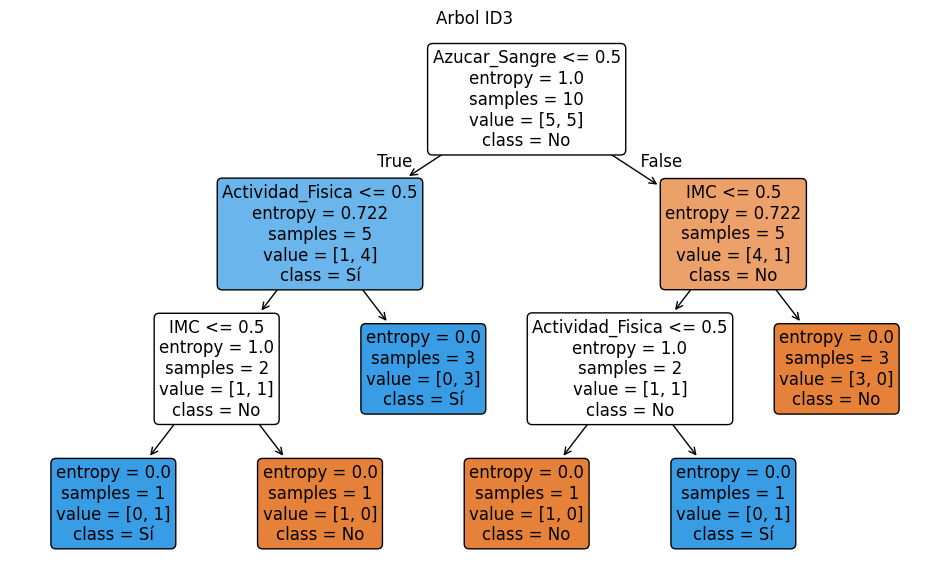

In [75]:
modelo_id3 = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

modelo_id3.fit(X, y)

plt.figure(figsize=(12,7))

plot_tree(
    modelo_id3,
    feature_names=[
        "IMC",
        "Azucar_Sangre",
        "Actividad_Fisica"
    ],
    class_names=["No","Sí"],
    filled=True,
    rounded=True
)

plt.title("Arbol ID3")
plt.show()

CART

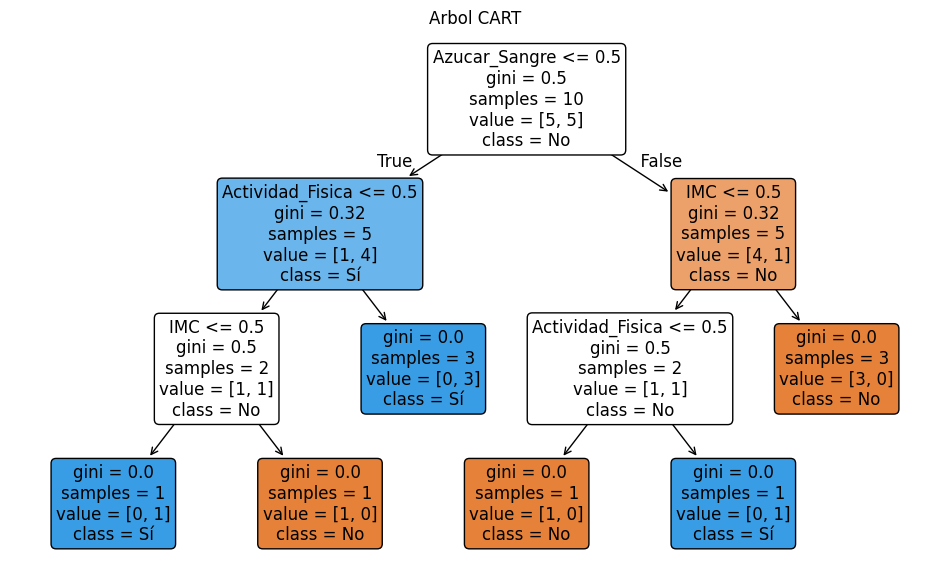

In [76]:
modelo_cart = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

modelo_cart.fit(X, y)

plt.figure(figsize=(12,7))

plot_tree(
    modelo_cart,
    feature_names=[
        "IMC",
        "Azucar_Sangre",
        "Actividad_Fisica"
    ],
    class_names=["No","Sí"],
    filled=True,
    rounded=True
)

plt.title("Arbol CART")
plt.show()


Predecir: ¿Un paciente con IMC=Alto, Azucar=Alta, Actividad=Poca?

In [77]:
print("Paciente: IMC=Alto, Azucar=Alta, Actividad=Poca")
pred = modelo_id3.predict([[0,0,1]])
print("Resultado:", "Sí" if pred[0] == 1 else "No")

Paciente: IMC=Alto, Azucar=Alta, Actividad=Poca
Resultado: Sí


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
